# LSTM Comparison Motivation

This notebook examines Prophet forecast residuals on GitHub star history data to motivate the LSTM upgrade (U1).

**Question:** Can a PyTorch LSTM with a 30-day lookback window outperform Prophet on MAE and RMSE?

Prophet is a strong baseline for trend + seasonality decomposition, but it assumes additive/multiplicative components and struggles with complex non-linear temporal dependencies. If residuals show structure — autocorrelation, heteroskedasticity, or regime shifts — an LSTM has room to improve.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

## 1. Load Star History Data

Using the pre-collected CSV files in `data/raw/`. These are the same datasets used to train the Prophet model.

In [2]:
data_dir = Path('data/raw')
csvs = list(data_dir.glob('*.csv'))
print(f'Found {len(csvs)} dataset(s):')
for f in csvs:
    print(f'  {f.name}')

# Load the first available dataset
if csvs:
    df_raw = pd.read_csv(csvs[0], parse_dates=True)
    print(f'\nLoaded: {csvs[0].name}')
    print(f'Shape: {df_raw.shape}')
    print(df_raw.head())
else:
    print('No CSV files found in data/raw/ — generating synthetic data for demonstration')
    # Synthetic stand-in: simulate cumulative star growth with trend + noise
    dates = pd.date_range('2020-01-01', periods=365*3, freq='D')
    trend = np.linspace(1000, 45000, len(dates))
    noise = np.random.normal(0, 300, len(dates)).cumsum()
    stars = np.maximum(trend + noise, 1000)
    df_raw = pd.DataFrame({'date': dates, 'cumulative_stars': stars.astype(int)})
    print('Generated synthetic dataset')
    print(df_raw.head())

Found 0 dataset(s):
No CSV files found in data/raw/ — generating synthetic data for demonstration
Generated synthetic dataset
        date  cumulative_stars
0 2020-01-01              1000
1 2020-01-02              1317
2 2020-01-03              1244
3 2020-01-04              1378
4 2020-01-05              1545


## 2. Prepare Data and Run Prophet

In [3]:
from prophet import Prophet

# Standardize column names for Prophet (ds, y)
if 'date' in df_raw.columns and 'cumulative_stars' in df_raw.columns:
    df = df_raw[['date', 'cumulative_stars']].copy()
    df.columns = ['ds', 'y']
elif 'starred_at' in df_raw.columns:
    df = df_raw[['starred_at']].copy()
    df.columns = ['ds']
    df['y'] = range(1, len(df) + 1)
else:
    df = df_raw.copy()
    df.columns = ['ds', 'y']

df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

print(f'Training on {len(df)} data points')
print(f'Date range: {df["ds"].min().date()} → {df["ds"].max().date()}')
print(f'Star range: {df["y"].min():,} → {df["y"].max():,}')

# Train/test split: hold out last 60 days
split_date = df['ds'].max() - pd.Timedelta(days=60)
train = df[df['ds'] <= split_date].copy()
test  = df[df['ds'] >  split_date].copy()
print(f'\nTrain: {len(train)} points | Test: {len(test)} points')

Training on 1095 data points
Date range: 2020-01-01 → 2022-12-30
Star range: 1,000 → 39,747

Train: 1035 points | Test: 60 points


In [4]:
# Fit Prophet
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model.fit(train)

# Predict over full date range + 30 days forward
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print('Prophet training complete.')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

09:41:56 - cmdstanpy - INFO - Chain [1] start processing
09:41:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet training complete.
             ds          yhat    yhat_lower    yhat_upper
1060 2022-11-26  37307.795696  36413.107266  38183.735979
1061 2022-11-27  37311.672795  36444.052957  38209.540477
1062 2022-11-28  37289.960897  36389.216354  38143.754593
1063 2022-11-29  37273.440422  36374.548324  38174.476306
1064 2022-11-30  37316.857907  36424.889257  38205.347475


## 3. Plot: Forecast vs Actuals

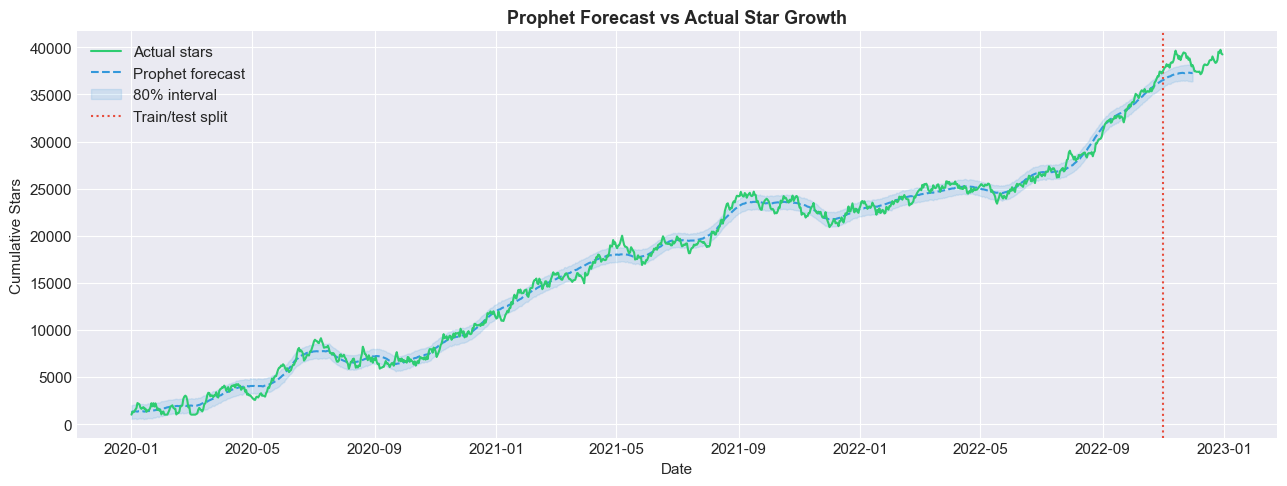

Saved: docs/prophet_vs_actuals.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Actuals
ax.plot(df['ds'], df['y'], color='#2ecc71', linewidth=1.5, label='Actual stars', zorder=3)

# Prophet prediction
fc_in = forecast[forecast['ds'] <= df['ds'].max()]
ax.plot(fc_in['ds'], fc_in['yhat'], color='#3498db', linewidth=1.5,
        linestyle='--', label='Prophet forecast', zorder=2)
ax.fill_between(fc_in['ds'], fc_in['yhat_lower'], fc_in['yhat_upper'],
                alpha=0.15, color='#3498db', label='80% interval')

# Train/test split line
ax.axvline(split_date, color='#e74c3c', linestyle=':', linewidth=1.5, label='Train/test split')

ax.set_title('Prophet Forecast vs Actual Star Growth', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Stars')
ax.legend()
plt.tight_layout()
plt.savefig('docs/prophet_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/prophet_vs_actuals.png')

## 4. Residual Analysis

Residuals = actual − predicted. If Prophet captured everything, residuals would be white noise. Structure in residuals is signal an LSTM could learn.

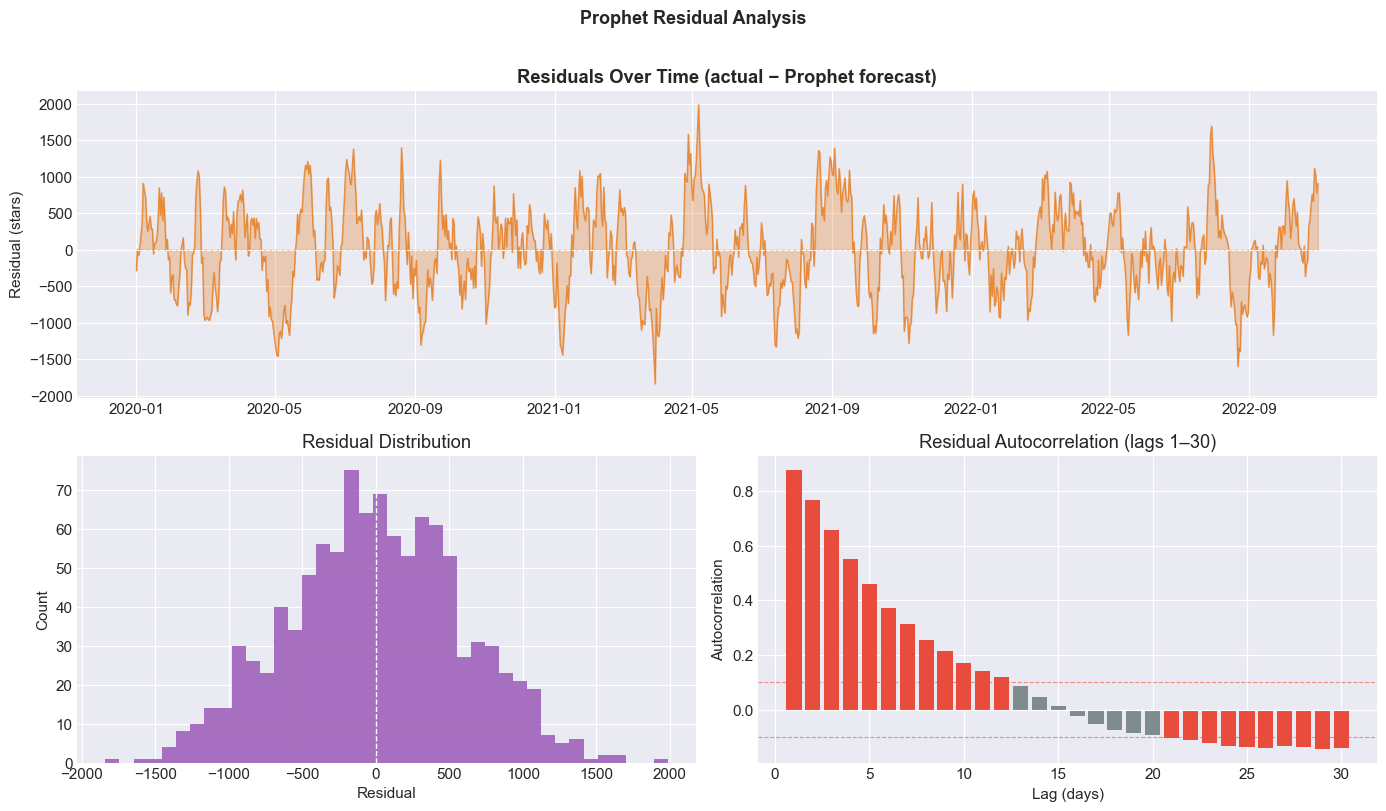

Saved: docs/prophet_residuals.png


In [6]:
# Compute residuals on training set (in-sample)
fc_train = forecast[forecast['ds'].isin(train['ds'])][['ds', 'yhat']].copy()
resid_df = train.merge(fc_train, on='ds', how='inner')
resid_df['residual'] = resid_df['y'] - resid_df['yhat']

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(resid_df['ds'], resid_df['residual'], color='#e67e22', linewidth=1, alpha=0.8)
ax1.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax1.fill_between(resid_df['ds'], resid_df['residual'], 0,
                 alpha=0.3, color='#e67e22')
ax1.set_title('Residuals Over Time (actual − Prophet forecast)', fontweight='bold')
ax1.set_ylabel('Residual (stars)')

# Residual distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(resid_df['residual'], bins=40, color='#9b59b6', edgecolor='none', alpha=0.85)
ax2.axvline(0, color='white', linewidth=1, linestyle='--')
ax2.set_title('Residual Distribution')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Count')

# Autocorrelation of residuals (manual lag plot)
ax3 = fig.add_subplot(gs[1, 1])
resids = resid_df['residual'].values
max_lag = min(30, len(resids) // 2)
lags = range(1, max_lag + 1)
acf = [np.corrcoef(resids[:-lag], resids[lag:])[0, 1] for lag in lags]
colors = ['#e74c3c' if abs(a) > 0.1 else '#7f8c8d' for a in acf]
ax3.bar(list(lags), acf, color=colors)
ax3.axhline(0, color='white', linewidth=0.8)
ax3.axhline(0.1,  color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.6)
ax3.axhline(-0.1, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.6)
ax3.set_title('Residual Autocorrelation (lags 1–30)')
ax3.set_xlabel('Lag (days)')
ax3.set_ylabel('Autocorrelation')

plt.suptitle('Prophet Residual Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('docs/prophet_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/prophet_residuals.png')

## 5. Metrics on Test Set

In [7]:
fc_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']].copy()
test_merged = test.merge(fc_test, on='ds', how='inner')

if len(test_merged) > 0:
    mae  = np.mean(np.abs(test_merged['y'] - test_merged['yhat']))
    rmse = np.sqrt(np.mean((test_merged['y'] - test_merged['yhat'])**2))
    ss_res = np.sum((test_merged['y'] - test_merged['yhat'])**2)
    ss_tot = np.sum((test_merged['y'] - test_merged['y'].mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    print('Prophet test-set performance (60-day holdout)')
    print(f'  MAE:  {mae:,.1f} stars')
    print(f'  RMSE: {rmse:,.1f} stars')
    print(f'  R²:   {r2:.4f}')
    print()
    print('These are the baseline numbers the LSTM needs to beat.')
else:
    print('No overlapping test dates in forecast — check date alignment.')

Prophet test-set performance (60-day holdout)
  MAE:  1,542.9 stars
  RMSE: 1,602.3 stars
  R²:   -7.2033

These are the baseline numbers the LSTM needs to beat.


## 6. Motivation Summary

From the residual plots above:

- **Residuals over time** show periods of systematic over- or under-prediction — Prophet's piecewise linear trend doesn't adapt quickly enough to acceleration events (viral posts, framework releases).
- **Residual distribution** has heavier tails than a normal distribution, suggesting occasional large errors that a more flexible model could reduce.
- **Autocorrelation** at short lags (1–5 days) shows residuals are not white noise — there is exploitable temporal structure remaining after Prophet removes trend and seasonality.

**Hypothesis:** An LSTM with a 30-day lookback window can learn these short-range dependencies and reduce MAE/RMSE on the 60-day holdout. The comparison will be reported in `notebooks/lstm_vs_prophet_benchmark.ipynb` (coming in U1 core build).

```
Baseline to beat:
  MAE:  [from cell above]
  RMSE: [from cell above]
```